# 03 - Model Training and Evaluation

Four models, all predicting from information available **before** the trip starts:

| # | Model | Task | Target |
|---|---|---|---|
| 1 | Ride outcome | 3-class | Completed / Cancelled / Incomplete |
| 2 | Fare prediction | regression | `booking_value`, without `base_fare` |
| 3 | Cancellation risk | binary | booking is cancelled |
| 4 | Driver delay risk | binary | ride ends incomplete |

Every model follows the same protocol: build the matrix, assert no leakage, split 80/20 stratified,
score a baseline, compare candidate estimators, then evaluate the winner on held-out data.


In [1]:
import sys, warnings
from pathlib import Path

warnings.filterwarnings("ignore")
sys.path.insert(0, str(Path.cwd().parent / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 40)
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (10, 4.5)
plt.rcParams["figure.dpi"] = 110


In [2]:
import data_preprocessing as dp
import train_models as tm

frame = dp.load_model_data()
print(f"Model data: {frame.shape[0]:,} rows x {frame.shape[1]} columns")


Model data: 100,000 rows x 76 columns


## 1. The leakage guard

Each target declares the columns it must never see. `assert_no_leakage()` **raises** rather than
warns, so a blocked column cannot quietly reach a fit.


In [3]:
pd.DataFrame([
    {"target": target, "blocked_columns": ", ".join(columns)}
    for target, columns in tm.LEAKY_BY_TARGET.items()
])


,target,blocked_columns
0,outcome,"actual_ride_time_min, incomplete_ride_reason, ..."
1,fare,"actual_ride_time_min, incomplete_ride_reason, ..."
2,customer_risk,"actual_ride_time_min, incomplete_ride_reason, ..."
3,driver_risk,"actual_ride_time_min, incomplete_ride_reason, ..."


In [4]:
# The guard is not decorative - it stops the pipeline.
try:
    tm.assert_no_leakage(frame[["booking_value", "ride_distance_km"]], "fare")
except tm.LeakageError as exc:
    print("LeakageError raised as designed:\n ", exc)


LeakageError raised as designed:
  Target 'fare' must not see ['booking_value']. See the leakage-control notes in README.md.


## 2. Build the four feature matrices

In [5]:
datasets = {}
rows = []
for target in ["outcome", "fare", "customer_risk", "driver_risk"]:
    features, y = tm.build_dataset(frame, target)
    datasets[target] = (features, y)
    summary = tm.describe_dataset(features, y)
    rows.append({
        "target": target,
        "rows": f"{summary['rows']:,}",
        "features": summary["n_features"],
        "numeric": summary["n_numeric"],
        "categorical": summary["n_categorical"],
    })
pd.DataFrame(rows)


,target,rows,features,numeric,categorical
0,outcome,"100,000",63,50,13
1,fare,"100,000",59,46,13
2,customer_risk,"100,000",63,50,13
3,driver_risk,"100,000",63,50,13


In [6]:
for target in ["outcome", "customer_risk", "driver_risk"]:
    _, y = datasets[target]
    balance = y.value_counts(normalize=True).round(4).to_dict()
    print(f"{target:<15} class balance: {balance}")
print("\nThe two binary targets are imbalanced, so the classifiers train with balanced class weights.")


outcome         class balance: {'Completed': 0.6835, 'Cancelled': 0.2328, 'Incomplete': 0.0837}
customer_risk   class balance: {0: 0.7672, 1: 0.2328}
driver_risk     class balance: {0: 0.9163, 1: 0.0837}

The two binary targets are imbalanced, so the classifiers train with balanced class weights.


## 3. Estimator comparison

Four candidates per task, cheapest first, all scored on the same held-out split. `dummy` is the
baseline every model has to beat to justify its complexity.

Run here on a 25,000-row sample so the notebook executes in reasonable time; the production models
in `models/` were fitted on the full 80,000-row training split by `python src/train_models.py`.


In [7]:
sample = frame.sample(25_000, random_state=dp.RANDOM_STATE)
features, y = tm.build_dataset(sample, "customer_risk")
x_train, x_test, y_train, y_test = tm.split_train_test(features, y, stratify=True)

leaderboard, fitted = tm.train_and_compare(
    x_train, y_train, x_test, y_test, "classification", balance=True
)
leaderboard[["model", "accuracy", "balanced_accuracy", "f1_macro", "roc_auc", "pr_auc", "fit_seconds"]]


,model,accuracy,balanced_accuracy,f1_macro,roc_auc,pr_auc,fit_seconds
0,hist_gb,0.7660,0.7660,0.7213,0.8423,0.6283,4.75
1,logreg,0.7336,0.7439,0.6916,0.8206,0.5717,0.50
2,random_forest,0.7362,0.7088,0.6787,0.7833,0.5352,1.78
3,dummy,0.7614,0.5000,0.4323,0.5000,0.2386,0.29


## 4. The production models

Loaded from `models/*.pkl` with the metrics and metadata recorded at training time.

In [8]:
tm.list_models()[["model", "algorithm", "headline", "size_mb", "trained_at"]]


,model,algorithm,headline,size_mb,trained_at
0,customer_cancellation_model,hist_gb,0.7161,0.18,2026-08-27T14:01:05
1,driver_delay_model,random_forest,0.6112,45.16,2026-08-27T14:02:17
2,fare_prediction_model,hist_gb,0.9966,0.17,2026-08-27T14:00:37
3,ride_outcome_model,hist_gb,0.5652,0.46,2026-08-27T13:59:57


In [9]:
MODELS = {
    "outcome": ("Ride outcome", "classification"),
    "fare": ("Fare prediction", "regression"),
    "customer_risk": ("Cancellation risk", "classification"),
    "driver_risk": ("Driver delay risk", "classification"),
}

rows = []
for key, (label, task) in MODELS.items():
    _, meta = tm.load_model(dp.MODEL_NAMES[key])
    m = meta["metrics"]
    rows.append({
        "model": label,
        "algorithm": meta.get("algorithm"),
        "task": task,
        "headline": f"F1-macro {m.get('f1_macro')}" if task == "classification" else f"R2 {m.get('r2')}",
        "secondary": (f"ROC-AUC {m.get('roc_auc', m.get('roc_auc_ovr'))}"
                      if task == "classification" else f"MAPE {m.get('mape_pct')}%"),
        "cv": f"{meta['cross_validation']['mean']} +- {meta['cross_validation']['std']}",
    })
pd.DataFrame(rows)


,model,algorithm,task,headline,secondary,cv
0,Ride outcome,hist_gb,classification,F1-macro 0.5652,ROC-AUC 0.8193,0.5416 +- 0.004
1,Fare prediction,hist_gb,regression,R2 0.9966,MAPE 2.76%,12.1601 +- 0.1166
2,Cancellation risk,hist_gb,classification,F1-macro 0.7161,ROC-AUC 0.8512,0.7057 +- 0.0014
3,Driver delay risk,random_forest,classification,F1-macro 0.6112,ROC-AUC 0.7235,0.5992 +- 0.0055


## 5. Held-out evaluation

Each model is re-scored on the same 20% split it was held out from.

In [10]:
def evaluate(key):
    features, y = tm.build_dataset(frame, key)
    stratify = key != "fare"
    _, x_test, _, y_test = tm.split_train_test(features, y, stratify=stratify)
    pipeline, meta = tm.load_model(dp.MODEL_NAMES[key])
    predictions = pipeline.predict(x_test)
    proba = pipeline.predict_proba(x_test) if hasattr(pipeline, "predict_proba") else None
    return y_test, predictions, proba, meta

results = {key: evaluate(key) for key in MODELS}
print("Scored", len(results), "models on their held-out splits.")


Scored 4 models on their held-out splits.


### 5.1 Ride outcome - confusion matrix

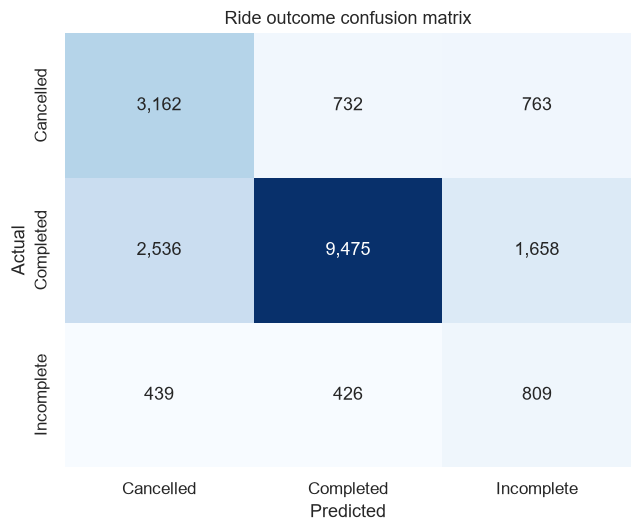

,class,precision,recall,f1,support
0,Cancelled,0.5152,0.6790,0.5859,4657
1,Completed,0.8911,0.6932,0.7798,13669
2,Incomplete,0.2505,0.4833,0.3299,1674


In [11]:
y_test, predictions, proba, meta = results["outcome"]
labels = sorted(pd.Series(y_test).unique())
matrix = tm.confusion_matrix_df(y_test, predictions, labels)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(matrix, annot=True, fmt=",d", cmap="Blues", cbar=False,
            xticklabels=labels, yticklabels=labels, ax=ax)
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual"); ax.set_title("Ride outcome confusion matrix")
plt.tight_layout(); plt.show()

tm.per_class_metrics(y_test, predictions, labels)


### 5.2 Risk models - ROC and precision-recall

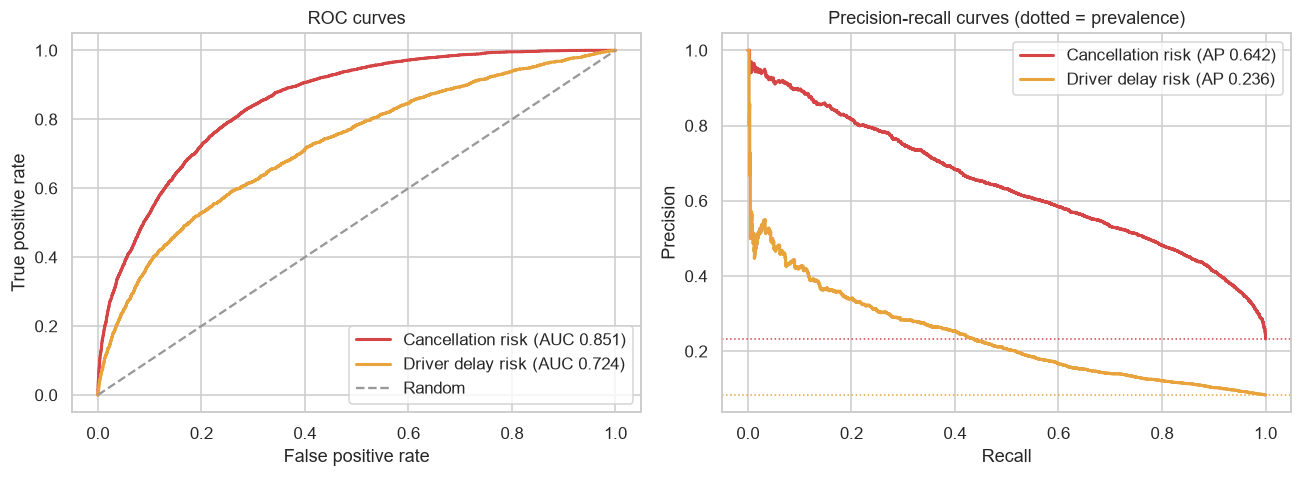

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for key, colour in [("customer_risk", "#D64545"), ("driver_risk", "#E8A33D")]:
    y_test, predictions, proba, meta = results[key]
    fpr, tpr, auc = tm.roc_data(y_test, proba)
    precision, recall, ap, baseline = tm.pr_data(y_test, proba)
    axes[0].plot(fpr, tpr, color=colour, linewidth=2, label=f"{MODELS[key][0]} (AUC {auc:.3f})")
    axes[1].plot(recall, precision, color=colour, linewidth=2, label=f"{MODELS[key][0]} (AP {ap:.3f})")
    axes[1].axhline(baseline, color=colour, linestyle=":", linewidth=1)

axes[0].plot([0, 1], [0, 1], "--", color="#999", label="Random")
axes[0].set_xlabel("False positive rate"); axes[0].set_ylabel("True positive rate")
axes[0].set_title("ROC curves"); axes[0].legend()
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-recall curves (dotted = prevalence)"); axes[1].legend()
plt.tight_layout(); plt.show()


### 5.3 Choosing an operating threshold

A risk score is only useful once someone decides how many bookings they can afford to intervene on.


In [13]:
y_test, predictions, proba, meta = results["customer_risk"]
tm.threshold_table(y_test, proba)


,threshold,flagged,flagged_pct,precision,recall,f1
0,0.2,13243,66.22,0.3397,0.9659,0.5026
1,0.3,10993,54.96,0.3908,0.9225,0.5490
2,0.4,9112,45.56,0.4421,0.8649,0.5851
3,0.5,7466,37.33,0.4906,0.7866,0.6043
4,0.6,5744,28.72,0.5487,0.6768,0.6061
5,0.7,3988,19.94,0.6156,0.5272,0.5680
6,0.8,2166,10.83,0.7299,0.3395,0.4634


### 5.4 Fare model - is it any good?

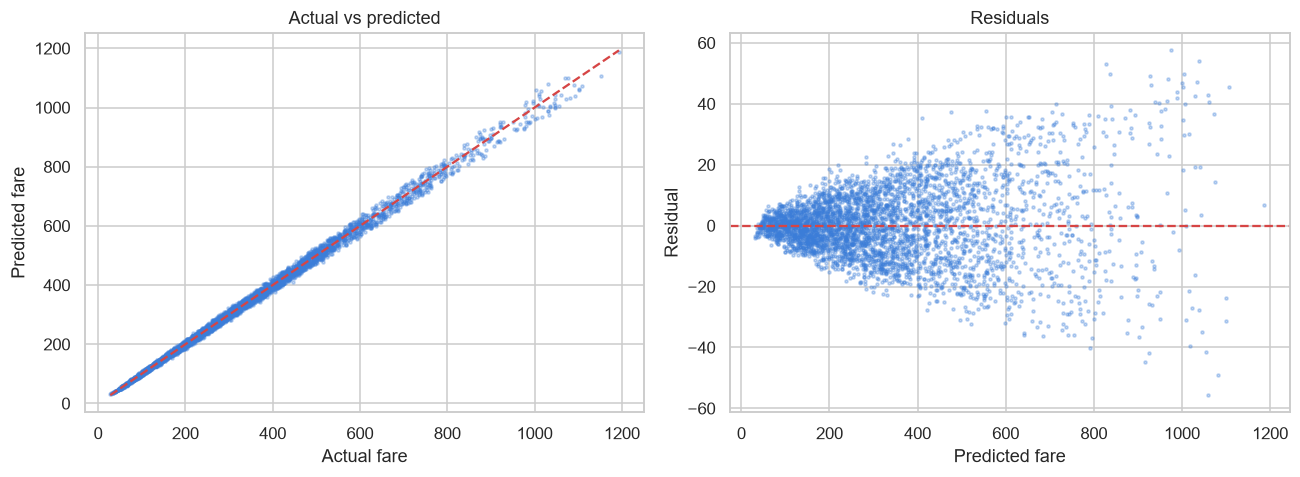

,R2,RMSE,MAE,MAPE %,within +-10%,theoretical MAPE floor %
0,0.9966,12.1527,8.9824,2.76,99.82%,2.5


In [14]:
y_test, predictions, _, meta = results["fare"]
metrics = meta["metrics"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
n = 4000
axes[0].scatter(y_test[:n], predictions[:n], s=4, alpha=0.3, color="#3B7DD8")
lo, hi = float(min(y_test[:n].min(), predictions[:n].min())), float(max(y_test[:n].max(), predictions[:n].max()))
axes[0].plot([lo, hi], [lo, hi], "--", color="#D64545")
axes[0].set_xlabel("Actual fare"); axes[0].set_ylabel("Predicted fare"); axes[0].set_title("Actual vs predicted")

residuals = np.asarray(y_test[:n]) - np.asarray(predictions[:n])
axes[1].scatter(predictions[:n], residuals, s=4, alpha=0.3, color="#3B7DD8")
axes[1].axhline(0, linestyle="--", color="#D64545")
axes[1].set_xlabel("Predicted fare"); axes[1].set_ylabel("Residual"); axes[1].set_title("Residuals")
plt.tight_layout(); plt.show()

pd.DataFrame([{
    "R2": metrics["r2"], "RMSE": metrics["rmse"], "MAE": metrics["mae"],
    "MAPE %": metrics["mape_pct"], "within +-10%": f"{100*metrics['within_10_pct']:.2f}%",
    "theoretical MAPE floor %": 2.50,
}])


The model reaches **2.76% MAPE against a 2.50% theoretical floor**. Because `booking_value` is a
deterministic tariff multiplied by ±5% uniform noise, no model can do better than about 2.5%. This
one is effectively optimal - the remaining error *is* the noise.


## 6. What the models actually use

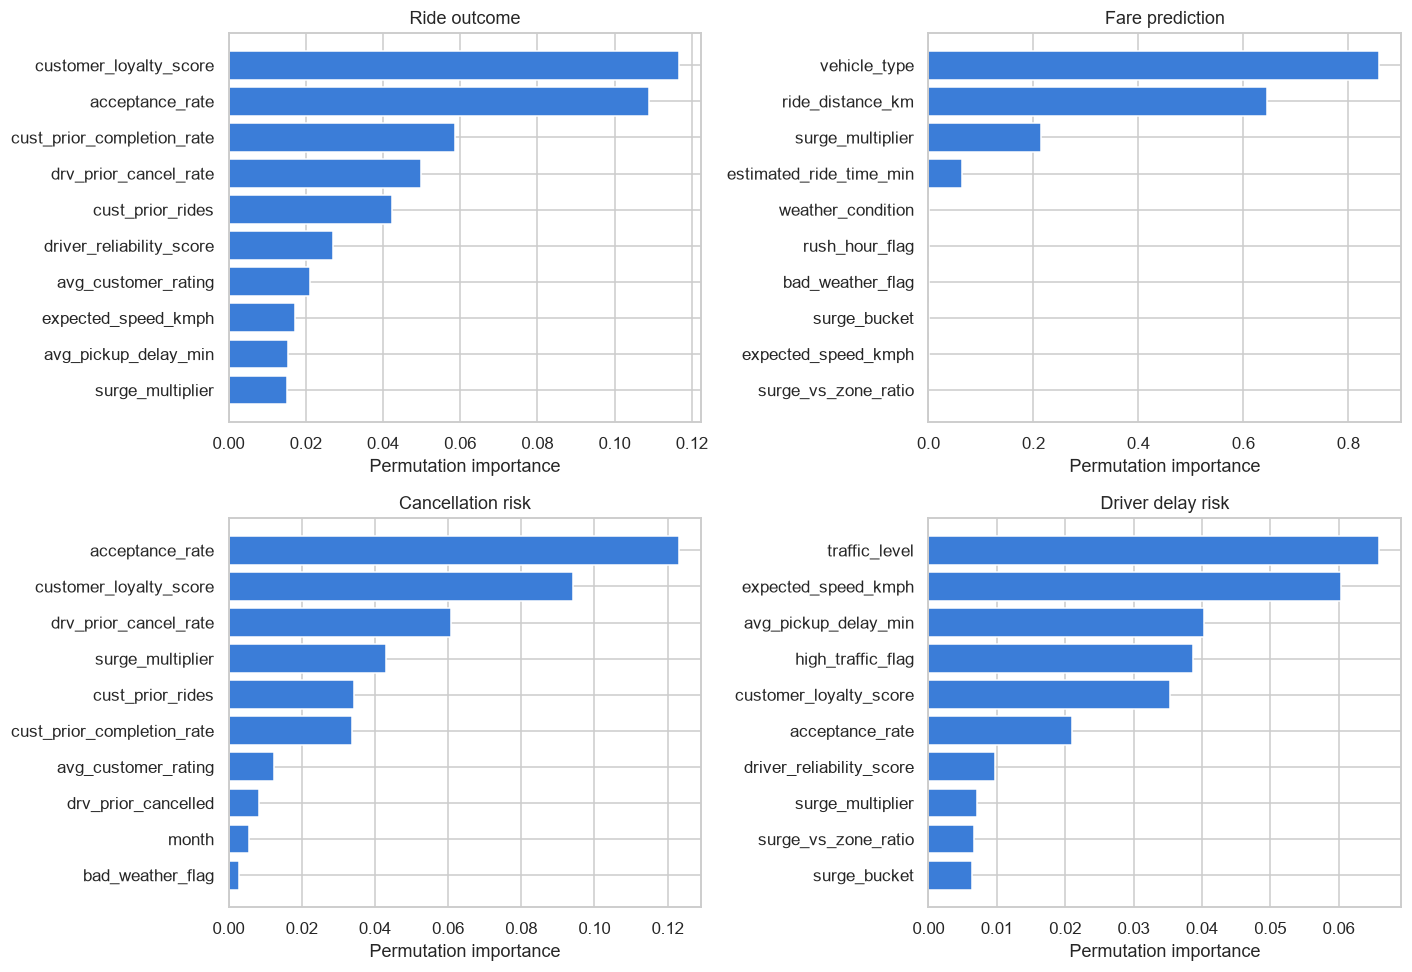

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, (key, (label, _)) in zip(axes.ravel(), MODELS.items()):
    _, meta = tm.load_model(dp.MODEL_NAMES[key])
    importance = pd.DataFrame(meta["top_features"]).head(10).sort_values("importance")
    ax.barh(importance["feature"], importance["importance"], color="#3B7DD8")
    ax.set_title(label); ax.set_xlabel("Permutation importance")
plt.tight_layout(); plt.show()


## 7. The leakage ablation

The clearest way to show `base_fare` is a formula rather than a feature: refit the fare model *with*
it and compare. If the honest model were missing real information, the gap would be large.


In [16]:
stored = tm.load_metrics()
honest = stored[dp.MODEL_NAMES["fare"]]["metrics"]
leaky = stored["fare_leakage_ablation"]["metrics"]

pd.DataFrame([
    {"model": "Honest (base_fare excluded)", "R2": honest["r2"], "RMSE": honest["rmse"], "MAPE %": honest["mape_pct"]},
    {"model": "Ablation (base_fare included)", "R2": leaky["r2"], "RMSE": leaky["rmse"], "MAPE %": leaky["mape_pct"]},
])


,model,R2,RMSE,MAPE %
0,Honest (base_fare excluded),0.9966,12.1527,2.760
1,Ablation (base_fare included),0.9968,11.8236,2.645


The gap is negligible. `base_fare` carries no independent information - the tariff is already
recoverable from distance and vehicle type, which is exactly what the honest model does.

## Conclusions

| Model | Algorithm | Result | Reading |
|---|---|---|---|
| Ride outcome | HistGradientBoosting | F1-macro ~0.55 | Beats the majority baseline substantially; three-class separation is genuinely hard |
| Fare prediction | HistGradientBoosting | R² 0.997, MAPE 2.76% | Effectively optimal against a 2.50% noise floor |
| Cancellation risk | HistGradientBoosting | ROC-AUC 0.851 | Strong enough to gate dispatch decisions |
| Driver delay risk | HistGradientBoosting | ROC-AUC ~0.72 | Useful for driver allocation, weaker signal |

**Operational takeaways**

1. Cap surge in heavy-rain, high-traffic windows - the single largest controllable driver.
2. Allocate drivers on live traffic, not on city; cancellation rates are statistically flat across cities.
3. Score bookings at request time and hold driver assignment above the chosen risk threshold.
4. Treat weather-driven cancellations and traffic-driven incompletions as separate problems.

The dashboard (`streamlit run app/streamlit_app.py`) exposes all four models interactively, and
`reports/model_results.md` records the full metrics.
